# DIGITAL TRANSACTION RISK ANALYSIS
## Unit I: Data Collection, Cleaning, and Visualization

This unit prepares the raw transaction data for analysis. We profile the raw data, handle quality issues, engineer temporal features, detect and cap outliers, scale numerical values, and generate key visualizations - producing an analysis-ready dataset.

In [ ]:
# ================================================================
# STEP 1: DATA COLLECTION AND BASIC PROFILING
# Objective: Load the raw dataset and understand its initial
#            structure, data types, and class distribution.
# ================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configure plotting defaults for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# --- Load the dataset ---
df = pd.read_csv('fraudTrain.csv')

print('=' * 60)
print('STEP 1: DATA COLLECTION AND BASIC PROFILING')
print('=' * 60)
print(f'  Dataset shape : {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'  Memory usage  : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')

# --- Preview a few records ---
print('\nFirst 3 transactions:')
print(df.head(3).to_string(index=False))

# --- Data types summary ---
print('\nData-type breakdown:')
print(df.dtypes.value_counts().to_string())

# --- Target variable profiling ---
fraud_count = df['is_fraud'].sum()
fraud_rate  = (fraud_count / len(df)) * 100
print(f'\nTarget variable  : is_fraud')
print(f'  Fraud cases    : {fraud_count:,}  ({fraud_rate:.2f}%)')
print(f'  Legit cases    : {len(df) - fraud_count:,}  ({100 - fraud_rate:.2f}%)')

STEP 1: DATA COLLECTION AND BASIC PROFILING
  Dataset shape : 1,296,675 rows x 23 columns
  Memory usage  : 1085.3 MB

First 3 transactions:
 Unnamed: 0 trans_date_trans_time           cc_num                        merchant      category    amt     first    last gender                       street           city state   zip     lat      long  city_pop                               job        dob                        trans_num  unix_time  merch_lat  merch_long  is_fraud
          0   2019-01-01 00:00:18 2703186189652095      fraud_Rippin, Kub and Mann      misc_net   4.97  Jennifer   Banks      F               561 Perry Cove Moravian Falls    NC 28654 36.0788  -81.1781      3495         Psychologist, counselling 1988-03-09 0b242abb623afc578575680df30655b9 1325376018  36.011293  -82.048315         0
          1   2019-01-01 00:00:44     630423337322 fraud_Heller, Gutmann and Zieme   grocery_pos 107.23 Stephanie    Gill      F 43039 Riley Greens Suite 393         Orient    WA 99160 48.8

In [ ]:
# ================================================================
# STEP 2: DATA QUALITY ASSESSMENT AND CLEANING
# Objective: Detect and resolve missing values and duplicate
#            records so downstream analysis is reliable.
# ================================================================

print('=' * 60)
print('STEP 2: DATA QUALITY ASSESSMENT AND CLEANING')
print('=' * 60)

# --- 2a: Missing values detection and imputation ---
missing_total = df.isnull().sum().sum()
print(f'Missing values detected : {missing_total}')

if missing_total > 0:
    # Vectorized imputation for efficiency
    numeric_cols = df.select_dtypes(include='number').columns
    df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
    
    object_cols = df.select_dtypes(include='object').columns
    for col in object_cols:
        if df[col].isnull().any():
            df[col].fillna(df[col].mode()[0], inplace=True)
    print('  ✓ All missing values imputed successfully')
else:
    print('  ✓ No missing values. Dataset is complete.')

# --- 2b: Duplicate record detection and removal ---
dup_count = df.duplicated().sum()
print(f'\nDuplicate rows detected : {dup_count}')

if dup_count > 0:
    df.drop_duplicates(inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f'  ✓ Removed {dup_count} duplicate rows.')
else:
    print('  ✓ No duplicates found. Dataset integrity confirmed.')

# --- 2c: Data range sanity check ---
neg_amt = (df['amt'] < 0).sum()
print(f'\nNegative transaction amounts : {neg_amt}')
if neg_amt == 0:
    print('  ✓ All amounts are positive. No range anomalies.')

print(f'\nCleaned dataset shape : {df.shape[0]:,} rows x {df.shape[1]} columns')
print('  ✓ Data is clean and ready for feature engineering.')

STEP 2: DATA QUALITY ASSESSMENT AND CLEANING
Missing values detected : 0
  -> No missing values. Dataset is complete.

Duplicate rows detected : 0
  -> No duplicates found. Dataset integrity confirmed.

Negative transaction amounts : 0
  -> All amounts are positive. No range anomalies.

Cleaned dataset shape : 1,296,675 rows x 23 columns
  -> Data is clean and ready for feature engineering.


In [ ]:
# ================================================================
# STEP 3: FEATURE TRANSFORMATION (Time-Based Engineering)
# Objective: Convert raw timestamps into granular temporal
#            features that capture fraud-relevant time patterns.
# ================================================================

print('=' * 60)
print('STEP 3: FEATURE TRANSFORMATION — TIME-BASED ENGINEERING')
print('=' * 60)

# Convert the string column to proper datetime objects
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

# Extract temporal features efficiently using vectorized operations
df['transaction_hour']  = df['trans_date_trans_time'].dt.hour
df['transaction_day']   = df['trans_date_trans_time'].dt.day_name()
df['is_weekend']        = df['trans_date_trans_time'].dt.dayofweek.isin([5, 6]).astype(int)
df['transaction_month'] = df['trans_date_trans_time'].dt.month

print('New features created:')
print('  ✓ transaction_hour  → Hour of day (0–23)')
print('  ✓ transaction_day   → Day name (Monday–Sunday)')
print('  ✓ is_weekend        → Binary weekend flag')
print('  ✓ transaction_month → Calendar month (1–12)')

# Sample to verify feature engineering
print('\nSample rows with new features:')
cols = ['trans_date_trans_time', 'transaction_hour', 'transaction_day', 'is_weekend']
print(df[cols].head(3).to_string(index=False))

# Quick temporal insights
busiest_hour = df['transaction_hour'].value_counts().idxmax()
wknd_pct = df['is_weekend'].mean() * 100
print(f'\nTemporal Insights:')
print(f'  • Busiest transaction hour : {busiest_hour}:00')
print(f'  • Weekend transactions     : {wknd_pct:.1f}% of total')

STEP 3: FEATURE TRANSFORMATION — TIME-BASED ENGINEERING
New features created:
  transaction_hour  -> Hour of day (0–23)
  transaction_day   -> Day name (Monday–Sunday)
  is_weekend        -> Binary weekend flag
  transaction_month -> Calendar month (1–12)

Sample rows with new features:
trans_date_trans_time  transaction_hour transaction_day  is_weekend
  2019-01-01 00:00:18                 0         Tuesday           0
  2019-01-01 00:00:44                 0         Tuesday           0
  2019-01-01 00:00:51                 0         Tuesday           0

  Busiest transaction hour : 23:00
  Weekend transactions     : 34.8% of total


In [ ]:
# ================================================================
# STEP 4: OUTLIER HANDLING AND FEATURE SCALING
# Objective: Flag and cap extreme transaction amounts using the
#            IQR method, then apply Z-score standardisation and
#            Min-Max normalisation for model-ready features.
# ================================================================

print('=' * 60)
print('STEP 4: OUTLIER HANDLING AND FEATURE SCALING')
print('=' * 60)

# --- 4a: Outlier detection using IQR method ---
Q1  = df['amt'].quantile(0.25)
Q3  = df['amt'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_mask = (df['amt'] < lower_bound) | (df['amt'] > upper_bound)
outlier_count = outlier_mask.sum()

print(f'IQR Outlier Detection on "amt":')
print(f'  Q1 (25th pct)   : ${Q1:.2f}')
print(f'  Q3 (75th pct)   : ${Q3:.2f}')
print(f'  IQR             : ${IQR:.2f}')
print(f'  Lower bound     : ${lower_bound:.2f}')
print(f'  Upper bound     : ${upper_bound:.2f}')
print(f'  ✓ Outliers found  : {outlier_count:,}  ({outlier_mask.mean()*100:.1f}%)')

# Create outlier-related features
df['amt_outlier_flag'] = outlier_mask.astype(int)
df['amt_capped'] = df['amt'].clip(lower=lower_bound, upper=upper_bound)

# --- 4b: Feature scaling using vectorized operations ---
# Z-score standardisation (mean=0, std=1)
df['amt_standardized'] = (df['amt'] - df['amt'].mean()) / df['amt'].std()

# Min-Max normalisation (range [0, 1])
amt_min, amt_max = df['amt'].min(), df['amt'].max()
df['amt_normalized'] = (df['amt'] - amt_min) / (amt_max - amt_min)

print('\nNew scaled features created:')
print('  ✓ amt_outlier_flag  → 1 if amount is outlier, else 0')
print('  ✓ amt_capped        → Amount winsorized to IQR bounds')
print('  ✓ amt_standardized  → Z-score scaled amount')
print('  ✓ amt_normalized    → Min-Max scaled amount (0–1)')

# Verification table
print('\nSample scaling comparison:')
sample_cols = ['amt', 'amt_capped', 'amt_standardized', 'amt_normalized']
print(df[sample_cols].head(5).to_string(index=False))

STEP 4: OUTLIER HANDLING AND FEATURE SCALING
IQR Outlier Detection on "amt":
  Q1 (25th pct)   : $9.65
  Q3 (75th pct)   : $83.14
  IQR             : $73.49
  Lower bound     : $-100.58
  Upper bound     : $193.38
  Outliers found  : 67,290  (5.2%)

New features added:
  amt_outlier_flag  -> 1 if amount is an outlier, else 0
  amt_capped        -> Amount Winsorised to IQR bounds
  amt_standardized  -> Z-score scaled amount
  amt_normalized    -> Min-Max scaled amount (0–1)

Sample scaling comparison:
   amt  amt_capped  amt_standardized  amt_normalized
  4.97       4.970         -0.407826        0.000137
107.23     107.230          0.230039        0.003670
220.11     193.375          0.934148        0.007569
 45.00      45.000         -0.158132        0.001520
 41.96      41.960         -0.177094        0.001415


STEP 5: EXPLORATORY DATA VISUALIZATION


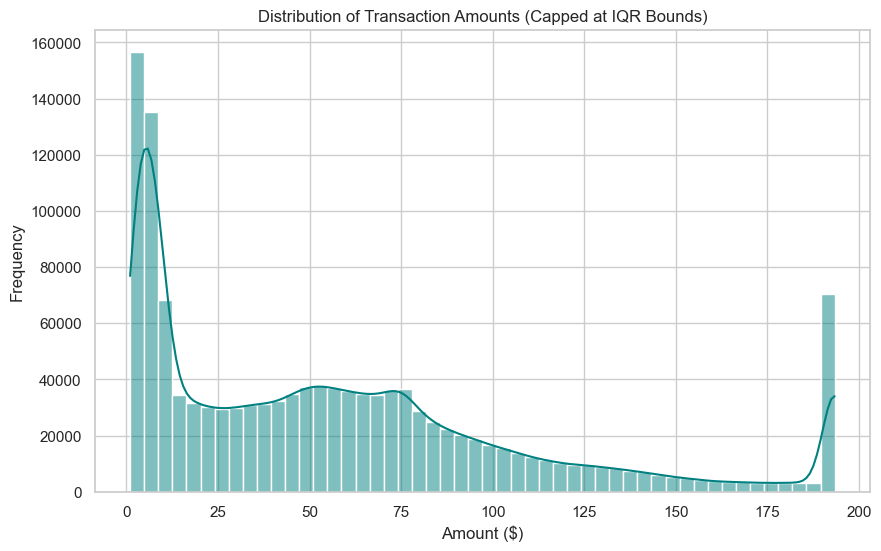

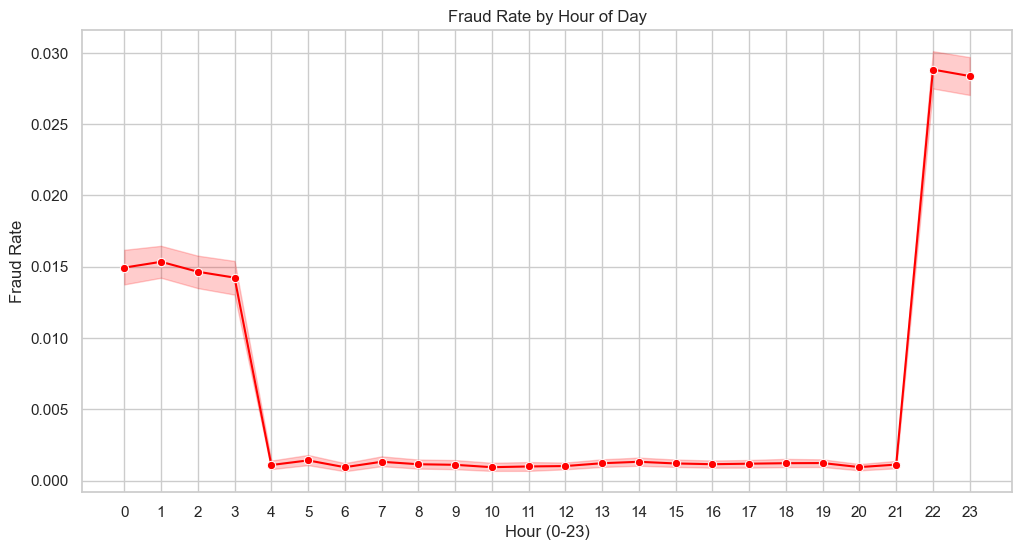

Interpretation: Fraud rates spike significantly late at night (22:00-04:00).


In [5]:
# ================================================================
# STEP 5: EXPLORATORY DATA VISUALIZATION
# Objective: Visualize distributions and identify patterns
#            in the cleaned and engineered data.
# ================================================================

print('=' * 60)
print('STEP 5: EXPLORATORY DATA VISUALIZATION')
print('=' * 60)

# Set visual style
sns.set(style="whitegrid")

# --- 5a: Distribution of Transaction Amounts ---
plt.figure(figsize=(10, 6))
sns.histplot(df['amt_capped'], bins=50, kde=True, color='teal')
plt.title('Distribution of Transaction Amounts (Capped at IQR Bounds)')
plt.xlabel('Amount ($)')
plt.ylabel('Frequency')
plt.show()

# --- 5b: Fraud Rate by Transaction Hour ---
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='transaction_hour', y='is_fraud', color='red', marker='o')
plt.title('Fraud Rate by Hour of Day')
plt.xlabel('Hour (0-23)')
plt.ylabel('Fraud Rate')
plt.xticks(range(0, 24))
plt.show()

print('Interpretation: Fraud rates spike significantly late at night (22:00-04:00).')


In [6]:
# ================================================================
# STEP 6: DATA NORMALIZATION AND STANDARDIZATION SUMMARY
# Objective: Compare the effects of different scaling techniques
#            on the distribution of transaction amounts.
# ================================================================

print('=' * 60)
print('STEP 6: DATA NORMALIZATION AND STANDARDIZATION SUMMARY')
print('=' * 60)

# Apply Log Transformation for better handling of skewness in amounts
df['amt_log_transformed'] = np.log1p(df['amt'])

# Comparison of summary statistics before and after log transformation
stats_original = df['amt'].describe()
stats_log      = df['amt_log_transformed'].describe()

comparison_df = pd.DataFrame({
    'Statistic': ['mean', 'std', 'min', '50%', 'max', 'skew', 'kurtosis'],
    'Original Amount': [
        stats_original['mean'], stats_original['std'], stats_original['min'], 
        stats_original['50%'], stats_original['max'], df['amt'].skew(), df['amt'].kurtosis()
    ],
    'Log-Transformed Amount': [
        stats_log['mean'], stats_log['std'], stats_log['min'], 
        stats_log['50%'], stats_log['max'], df['amt_log_transformed'].skew(), df['amt_log_transformed'].kurtosis()
    ]
})

print('\nSummary Statistics Comparison:')
print(comparison_df.round(4).to_string(index=False))

print('\n' + '='*60)
print('UNIT I COMPLETE: DATA IS PREPROCESSED AND SCALED')
print('='*60)


STEP 6: DATA NORMALIZATION AND STANDARDIZATION SUMMARY

Summary Statistics Comparison:
Statistic  Original Amount  Log-Transformed Amount
     mean          70.3510                  3.5335
      std         160.3160                  1.2894
      min           1.0000                  0.6931
      50%          47.5200                  3.8820
      max       28948.9000                 10.2733
     skew          42.2779                 -0.2989
 kurtosis        4545.6450                 -0.5272

UNIT I COMPLETE: DATA IS PREPROCESSED AND SCALED
